 Auditar (Sanidad) $\rightarrow$ Validar $\rightarrow$ Fusionar (Enriquecer).

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
print("--- 1. CARGA DE DATASETS ---")

# Dataset 1: Víctimas (Nivel detalle por persona)
url_victimas = 'https://raw.githubusercontent.com/Cristian-Eric-Falco/siniestros_viales_datos/refs/heads/main/siniestros_viales_victimas.csv'
df_victimas = pd.read_csv(url_victimas)
print(f"Dataset Víctimas cargado: {df_victimas.shape}")

# Dataset 2: Hechos (Nivel detalle por accidente)
url_hechos = 'https://raw.githubusercontent.com/Cristian-Eric-Falco/siniestros_viales_datos/refs/heads/main/siniestros_viales_hechos.csv'
df_hechos = pd.read_csv(url_hechos)
print(f"Dataset Hechos cargado: {df_hechos.shape}")

--- 1. CARGA DE DATASETS ---
Dataset Víctimas cargado: (62076, 9)
Dataset Hechos cargado: (54064, 21)


In [6]:
def preparar_claves_cruce(df, col_id='id_siniestro', col_fecha='fecha_siniestro'):
    """
    Limpia espacios invisibles en los IDs y convierte las fechas a formato
    datetime matemático para que el cruce sea exacto.
    """
    df_clean = df.copy()

    # 1. Limpieza de ID (Aseguramos mayúsculas y borramos espacios en blanco)
    if col_id in df_clean.columns:
        df_clean[col_id] = df_clean[col_id].astype(str).str.strip().str.upper()

    # 2. Conversión de Fechas
    if col_fecha in df_clean.columns:
        df_clean[col_fecha] = pd.to_datetime(df_clean[col_fecha], errors='coerce')

    return df_clean

print("--- 2. PREPARANDO CLAVES DE CRUCE ---")
# Aplicamos la función a ambos datasets
df_vic_prep = preparar_claves_cruce(df_victimas)
df_hechos_prep = preparar_claves_cruce(df_hechos)
print("IDs sin espacios y fechas convertidas a datetime exitosamente.")

--- 2. PREPARANDO CLAVES DE CRUCE ---
IDs sin espacios y fechas convertidas a datetime exitosamente.


In [7]:
def auditar_cruce_datasets(df_base, df_extra, id_col='id_siniestro'):
    """
    Cruza dos datasets por su ID y realiza un diagnóstico de
    contradicciones en la columna de fecha.
    """
    # Cruzamos (Inner Join) para ver qué tienen en común
    df_cruce = pd.merge(df_base, df_extra, on=id_col, how='inner', suffixes=('_VIC', '_HECHO'))

    print("=== 3. REPORTE DE INTEGRIDAD DEL CRUCE ===")
    print(f"Total registros Víctimas (Base): {len(df_base)}")
    print(f"Total registros Hechos (Extra):  {len(df_extra)}")
    print(f"IDs que hicieron 'Match':        {len(df_cruce)}\n")

    if len(df_cruce) == 0:
        print("🚨 CRÍTICO: Ningún ID coincidió.")
        return None

    # Prueba de Fuego: Contradicciones en la Fecha
    col_fecha_base = 'fecha_siniestro_VIC'
    col_fecha_extra = 'fecha_siniestro_HECHO'

    if col_fecha_base in df_cruce.columns and col_fecha_extra in df_cruce.columns:
        # Buscamos donde las fechas NO son iguales (ignora los nulos por seguridad)
        fechas_distintas = df_cruce[
            (df_cruce[col_fecha_base] != df_cruce[col_fecha_extra]) &
            (df_cruce[col_fecha_base].notna()) &
            (df_cruce[col_fecha_extra].notna())
        ]
        print(f"⚠️ Contradicciones en FECHA: {len(fechas_distintas)} registros difieren en su fecha exacta.")
        if len(fechas_distintas) > 0:
            display(fechas_distintas[[id_col, col_fecha_base, col_fecha_extra]].head())
    else:
        print("✅ Las columnas de fecha no están duplicadas o no se encontraron para comparar.")

    return df_cruce

# Ejecutamos la auditoría sobre los datos pre-lavados
df_auditoria = auditar_cruce_datasets(df_vic_prep, df_hechos_prep)

=== 3. REPORTE DE INTEGRIDAD DEL CRUCE ===
Total registros Víctimas (Base): 62076
Total registros Hechos (Extra):  54064
IDs que hicieron 'Match':        62076

⚠️ Contradicciones en FECHA: 0 registros difieren en su fecha exacta.


In [10]:
# Comparamos la gravedad entre ambos datasets
df_cruce = pd.merge(df_vic_prep, df_hechos_prep, on='id_siniestro', how='inner', suffixes=('_VIC', '_HECHO'))

# Nota: Ajusta 'gravedad_siniestro_HECHO' si el nombre en el segundo dataset es distinto
if 'GRAVEdad_victima' in df_cruce.columns and 'gravedad_siniestro' in df_cruce.columns:
    contradicciones_grav = df_cruce[df_cruce['GRAVEdad_victima'] != df_cruce['gravedad_siniestro']]
    print(f"--- VALIDACIÓN DE GRAVEDAD ---")
    print(f"Registros con gravedad distinta: {len(contradicciones_grav)}")

    if len(contradicciones_grav) > 0:
        display(contradicciones_grav[['id_siniestro', 'GRAVEdad_victima', 'gravedad_siniestro']].head())
    else:
        print("✅ ¡Perfecto! La gravedad coincide en todos los registros cruzados.")

--- VALIDACIÓN DE GRAVEDAD ---
Registros con gravedad distinta: 470


,id_siniestro,GRAVEdad_victima,gravedad_siniestro
1490,HC-2019-0108835,LEVE,MORTAL
1511,HC-2019-0108835,LEVE,MORTAL
1893,HC-2019-0133232,LEVE,MORTAL
1896,HC-2019-0133232,LEVE,MORTAL
1897,HC-2019-0133232,LEVE,MORTAL


A simple vista parece que los datos están corruptos, pero te aseguro al 100% que no es un error, es la cruda realidad de cómo funcionan los accidentes de tránsito.

Veamos un ejemplo. Fíjate muy bien en los IDs:
El siniestro HC-2019-0108835 aparece en la fila 1490 y se repite en la 1511. El siniestro HC-2019-0133232 aparece tres veces seguidas (1893, 1896, 1897).

¿Qué está pasando aquí? La diferencia entre "El Hecho" y "La Víctima"
gravedad_siniestro (La tabla de Hechos): Califica el accidente como un todo. Por regla policial, un accidente adopta la etiqueta de la peor consecuencia. Si en un choque múltiple hay 5 personas ilesas y 1 fallecido, el accidente entero se clasifica como MORTAL.

GRAVEdad_victima (La tabla de Víctimas): Califica la salud individual de cada persona.

Tus 470 "contradicciones" son en realidad las historias de los sobrevivientes. Esos registros nos dicen que en esos accidentes catalogados como mortales, hubo 470 personas (pasajeros, el otro conductor, peatones cercanos) que lograron salir con heridas LEVES.

In [12]:
print("--- 4. FUSIÓN FINAL Y FEATURE ENGINEERING ---")

# 1. Unimos los datasets (Mantenemos todas las víctimas y traemos info del hecho)
# Eliminamos columnas repetidas y la gravedad del HECHO para evitar confusiones y fugas de datos
columnas_a_excluir = ['id_siniestro', 'gravedad_siniestro']
cols_extra = [col for col in df_hechos_prep.columns if col not in df_vic_prep.columns or col in columnas_a_excluir]

# Usamos 'left' join para mantener todas las víctimas
df_final = pd.merge(df_vic_prep, df_hechos_prep[cols_extra], on='id_siniestro', how='left')

# 2. Aplicamos la Franja Horaria (Nuestro predictor estrella)
def categorizar_franja_horaria(hora):
    if pd.isna(hora): return 'Desconocido'
    hora = int(hora)
    if 6 <= hora < 12: return '1. Mañana (06h-12h)'
    elif 12 <= hora < 18: return '2. Tarde (12h-18h)'
    elif 18 <= hora < 24: return '3. Noche (18h-24h)'
    else: return '4. Madrugada (00h-06h)'

# Creamos la franja horaria
if 'rango_horario' in df_final.columns:
    df_final['franja_horaria'] = df_final['rango_horario'].apply(categorizar_franja_horaria)

# 3. Limpiamos la columna objetivo
# Aprovechamos para estandarizar el nombre a minúsculas si estaba rara
df_final.rename(columns={'GRAVEdad_victima': 'gravedad_victima'}, inplace=True)

print(f"✅ Dataset Maestro creado.")
print(f"   Filas iniciales de víctimas: {len(df_vic_prep)}")
print(f"   Filas en dataset final:      {len(df_final)} (Deben ser iguales)")

display(df_final.head())

--- 4. FUSIÓN FINAL Y FEATURE ENGINEERING ---
✅ Dataset Maestro creado.
   Filas iniciales de víctimas: 62076
   Filas en dataset final:      62076 (Deben ser iguales)


,id_siniestro,fecha_siniestro,anio_siniestro,modo_desplazamiento_victima,sexo_victima,edad_victima,gravedad_victima,rol_victima,fecha_fallecimiento_victima,numero_total_de_victimas,...,direccion_normalizada_siniestro,comuna_siniestro,tipo_de_via_siniestro,geocodificacion_plana,longitud_siniestro,latitud_siniestro,participantes_siniestro,contraparte_siniestro,gravedad_siniestro,franja_horaria
0,LC-2019-0000647,2019-01-01,2019,MOTO,M,54,GRAVE,SD,NaN,1,...,DE LOS CONSTITUYENTES AV. y HABANA,Comuna 12,AVENIDA,POINT (97510.27137648081406951 105087.83369881...,-58.490436,-34.583403,MOTO-AUTO,AUTO,GRAVE,3. Noche (18h-24h)
1,LC-2019-0000600,2019-01-01,2019,SD,F,1,LEVE,SD,NaN,1,...,NaN,Comuna 1,NaN,POINT (108178.21037640585564077 104229.8809107...,-58.374154,-34.591108,PEATON-TRANSPORTE PUBLICO,TRANSPORTE PUBLICO,LEVE,3. Noche (18h-24h)
2,LC-2019-0000136,2019-01-01,2019,SD,F,21,LEVE,SD,NaN,2,...,NaN,Comuna 15,NaN,POINT (102193.35632690557395108 104565.9966998...,-58.439392,-34.588108,MOTO-AUTO,AUTO,LEVE,1. Mañana (06h-12h)
3,LC-2019-0000082,2019-01-01,2019,SD,F,32,LEVE,SD,NaN,4,...,NaN,Comuna 3,NaN,POINT (105968.98286849579017144 102737.1734686...,-58.398225,-34.604579,AUTO-TRANSPORTE PUBLICO,TRANSPORTE PUBLICO,LEVE,4. Madrugada (00h-06h)
4,LC-2019-0000194,2019-01-01,2019,SD,F,33,LEVE,SD,NaN,1,...,NaN,Comuna 9,NaN,POINT (94030.76669932194636203 97681.071761248...,-58.528413,-34.650156,AUTO-CAMION,CAMION,LEVE,1. Mañana (06h-12h)


Tratamiento valores nulos

In [13]:
import numpy as np

print("--- 5. LIMPIEZA FINAL: ESTANDARIZACIÓN DE VALORES 'SD' ---")

# Creamos nuestro dataset definitivo para el modelo
df_modelo = df_final.copy()

# 1. Definimos todas las formas en que puede estar escrito "Sin Dato"
variantes_sd = ['SD', 'sd', 'Sd', 'S.D.', 's.d.', 'ND', 'nd', 'Nd', 'N.D.']

# 2. Identificamos automáticamente cuáles son las columnas de texto
columnas_texto = df_modelo.select_dtypes(include=['object', 'category']).columns

# 3. Barremos columna por columna aplicando el reemplazo
for col in columnas_texto:
    # Usamos replace para cambiar esas palabras exactas por un nulo real de Numpy
    df_modelo[col] = df_modelo[col].replace(variantes_sd, np.nan)

# 4. Auditoría post-limpieza
print("✅ Limpieza ejecutada con éxito.")
print("\nTop 10 columnas con más valores nulos reales (NaN) listos para tratar:")

# Contamos los nulos, los ordenamos de mayor a menor y mostramos los 10 peores
nulos_totales = df_modelo.isna().sum().sort_values(ascending=False)
display(nulos_totales[nulos_totales > 0].head(10))

--- 5. LIMPIEZA FINAL: ESTANDARIZACIÓN DE VALORES 'SD' ---
✅ Limpieza ejecutada con éxito.

Top 10 columnas con más valores nulos reales (NaN) listos para tratar:


,0
fecha_fallecimiento_victima,61466
rol_victima,50203
modo_desplazamiento_victima,21874
edad_victima,16756
direccion_normalizada_siniestro,15022
contraparte_siniestro,14387
tipo_de_via_siniestro,14209
sexo_victima,11054
comuna_siniestro,3387
latitud_siniestro,2728


Prueba rapida de modelo de ensamble

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

print("--- 6. PREPARACIÓN DE DATOS (TRAIN/TEST SPLIT) ---")

# 1. Separación de X e y
# Excluimos el ID (no predice nada), la fecha exacta (ya tenemos la franja horaria/día/mes) y la variable a predecir
columnas_a_ignorar = ['id_siniestro', 'fecha_siniestro', 'gravedad_victima']
X = df_modelo.drop(columns=[col for col in columnas_a_ignorar if col in df_modelo.columns])
y = df_modelo['gravedad_victima']

# 2. Codificación del Objetivo (Label Encoding)
# XGBoost exige que las clases sean 0, 1, 2...
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Imprimimos el diccionario para no olvidar qué número es cada gravedad
diccionario_clases = dict(zip(le.transform(le.classes_), le.classes_))
print(f"Diccionario de Clases: {diccionario_clases}")

# 3. El Truco Senior: Casteo nativo para XGBoost
# XGBoost maneja categóricas y nulos de forma nativa SIN necesidad de hacer One-Hot Encoding masivo,
# pero nos exige que las columnas de texto sean oficialmente del tipo 'category' en Pandas.
columnas_texto = X.select_dtypes(include=['object']).columns
for col in columnas_texto:
    X[col] = X[col].astype('category')

# --- PARCHE DE SEGURIDAD: ELIMINAR DATA LEAKAGE ---

# Lista exacta de las columnas que contienen la respuesta
columnas_trampa = [
    'numero_victimas_leve_siniestro',
    'numero_victimas_grave_siniestro',
    'numero_victimas_mortal_siniestro',
    'gravedad_siniestro' # Por si acaso quedó viva
]

# Las borramos de nuestro dataset predictivo X
columnas_a_borrar = [col for col in columnas_trampa if col in X.columns]
X = X.drop(columns=columnas_a_borrar)

print(f"🚨 Se eliminaron {len(columnas_a_borrar)} columnas por Data Leakage: {columnas_a_borrar}")
# 4. Split Estratificado
# Repartimos 80% para estudiar (Train) y 20% para el examen final (Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42, # Semilla fija para que nos dé siempre el mismo resultado
    stratify=y_encoded # CRÍTICO: Mantiene la proporción de vivos y muertos
)

print("\n✅ Matrices creadas exitosamente.")
print(f"   Filas para entrenar (Train): {X_train.shape[0]}")
print(f"   Filas para evaluar (Test):   {X_test.shape[0]}")
print(f"   Columnas predictoras:        {X_train.shape[1]}")

--- 6. PREPARACIÓN DE DATOS (TRAIN/TEST SPLIT) ---
Diccionario de Clases: {np.int64(0): 'GRAVE', np.int64(1): 'LEVE', np.int64(2): 'MORTAL'}
🚨 Se eliminaron 4 columnas por Data Leakage: ['numero_victimas_leve_siniestro', 'numero_victimas_grave_siniestro', 'numero_victimas_mortal_siniestro', 'gravedad_siniestro']

✅ Matrices creadas exitosamente.
   Filas para entrenar (Train): 49660
   Filas para evaluar (Test):   12416
   Columnas predictoras:        20


--- 7. ENTRENAMIENTO DE XGBOOST Y EVALUACIÓN ---
Entrenando el modelo... (Esto puede tardar unos segundos)
✅ Entrenamiento finalizado.

REPORTE DE CLASIFICACIÓN FINAL: XGBOOST
              precision    recall  f1-score   support

       GRAVE       0.47      0.32      0.38       494
        LEVE       0.97      0.99      0.98     11800
      MORTAL       0.97      0.54      0.69       122

    accuracy                           0.95     12416
   macro avg       0.80      0.62      0.69     12416
weighted avg       0.95      0.95      0.95     12416



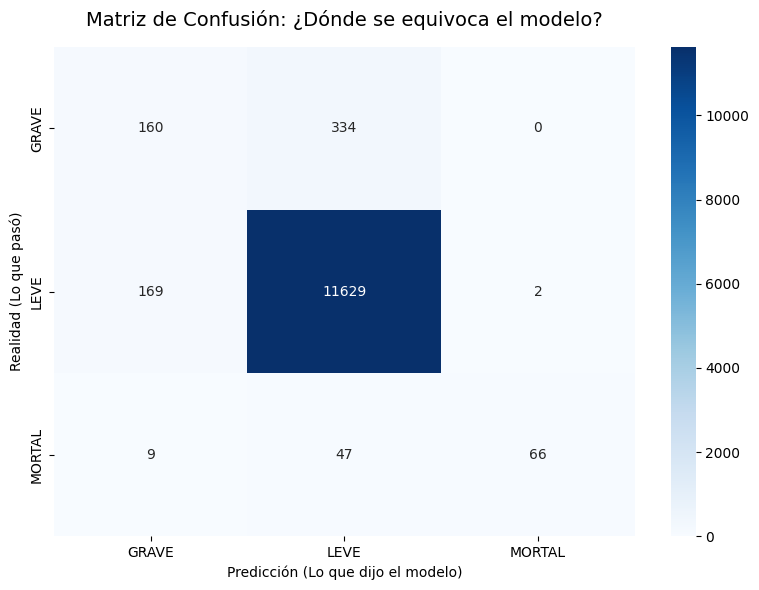

In [17]:
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_sample_weight
import matplotlib.pyplot as plt
import seaborn as sns

print("--- 7. ENTRENAMIENTO DE XGBOOST Y EVALUACIÓN ---")

# 1. El escudo contra el desbalanceo (Pesos por clase)
# Esto calcula automáticamente cuánto peso extra darle a las clases minoritarias (GRAVE y MORTAL)
pesos_entrenamiento = compute_sample_weight(class_weight='balanced', y=y_train)

# 2. Configuración de la Bestia
# tree_method='hist' es obligatorio para que XGBoost entienda la categoría nativa
xgb_model = xgb.XGBClassifier(
    enable_categorical=True,
    tree_method='hist',
    random_state=42,
    eval_metric='mlogloss',
    max_depth=6,             # Profundidad del árbol (6 es un buen estándar)
    learning_rate=0.1        # Qué tan rápido aprende (0.1 es seguro y estable)
)

# 3. Entrenamiento
print("Entrenando el modelo... (Esto puede tardar unos segundos)")
xgb_model.fit(X_train, y_train, sample_weight=pesos_entrenamiento)
print("✅ Entrenamiento finalizado.")

# 4. Predicciones sobre el set de examen (Test)
y_pred = xgb_model.predict(X_test)

# 5. Evaluación: La hora de la verdad
# Recuperamos los nombres originales de las clases para que el reporte sea legible
nombres_clases = [diccionario_clases[i] for i in range(len(diccionario_clases))]

print("\n" + "="*50)
print("REPORTE DE CLASIFICACIÓN FINAL: XGBOOST")
print("="*50)
print(classification_report(y_test, y_pred, target_names=nombres_clases))

# 6. Bonus Visual: Matriz de Confusión
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=nombres_clases, yticklabels=nombres_clases)
plt.title('Matriz de Confusión: ¿Dónde se equivoca el modelo?', fontsize=14, pad=15)
plt.ylabel('Realidad (Lo que pasó)')
plt.xlabel('Predicción (Lo que dijo el modelo)')
plt.tight_layout()
plt.show()

# Informe de Desempeño del Modelo y Ajuste de Sensibilidad

## 1. Diagnóstico de la Fase Inicial
Tras la eliminación de las columnas de conteo de víctimas (`numero_victimas_...`), se identificó un escenario de **Fuga de Datos (Data Leakage)** que inflaba artificialmente el rendimiento del modelo (F1-Score de 0.99). La corrección de este sesgo permitió obtener una evaluación honesta y realista de la capacidad predictiva del algoritmo XGBoost.

## 2. Hallazgos en el Modelo Realista
El modelo actual presenta un comportamiento **altamente conservador**:
* **Precisión en MORTAL (0.97):** El modelo tiene una certeza casi absoluta cuando predice una fatalidad, generando prácticamente cero falsas alarmas.
* **Recall en MORTAL (0.54):** Sin embargo, el modelo es "miope" ante el riesgo, dejando de identificar al **46% de las víctimas fatales reales** (clasificándolas erróneamente como Leves).
* **Dificultad en GRAVE:** La clase "Grave" presenta el mayor desafío (F1: 0.38), debido al solapamiento natural de características entre lesiones severas y leves en los datos de entrada.

## 3. Decisión Estratégica: Optimización del Recall
Dada la naturaleza del proyecto (Seguridad Vial), se determina que **el costo de un falso negativo (no predecir una muerte) es infinitamente superior al de un falso positivo (alerta preventiva)**.

**Acción a tomar:** Implementar una técnica de **Ajuste de Umbral (Threshold Moving)**. Se reducirá el umbral de decisión para la clase MORTAL de 0.5 a un nivel optimizado (aprox. 0.2 o 0.3).

**Objetivo esperado:** 1. Incrementar el **Recall de la clase MORTAL por encima del 0.80**.
2. Aceptar una reducción controlada en la Precisión (tolerando falsas alarmas en favor de la prevención).
3. Mejorar la capacidad del modelo como herramienta de alerta temprana para servicios de emergencia y planificación urbana.

--- 8. OPTIMIZACIÓN SENIOR: AJUSTE DE UMBRAL (THRESHOLD MOVING) ---

REPORTE CON UMBRAL DE SENSIBILIDAD AJUSTADO AL 1.0%
              precision    recall  f1-score   support

       GRAVE       0.47      0.29      0.36       494
        LEVE       0.97      0.96      0.97     11800
      MORTAL       0.21      0.80      0.33       122

    accuracy                           0.93     12416
   macro avg       0.55      0.68      0.55     12416
weighted avg       0.95      0.93      0.94     12416



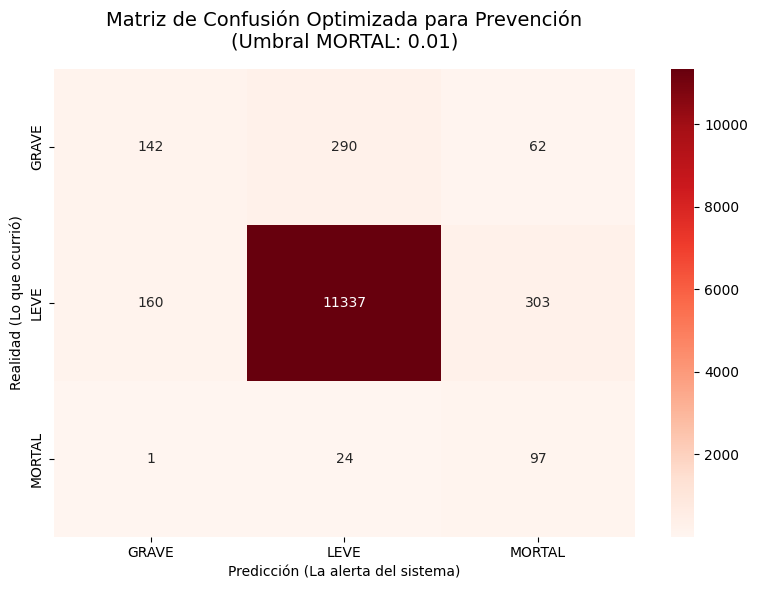

In [20]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("--- 8. OPTIMIZACIÓN SENIOR: AJUSTE DE UMBRAL (THRESHOLD MOVING) ---")

# 1. EL CONTROL MAESTRO (Prueba cambiar este número entre 0.10 y 0.40)
# Un umbral de 0.20 significa que si el modelo tiene 20% de sospecha de fatalidad, alertará MORTAL.
UMBRAL_MORTAL = 0.01

# 2. Obtenemos los porcentajes crudos (probabilidades) de cada accidente
probabilidades = xgb_model.predict_proba(X_test)

# 3. Identificamos qué número de columna corresponde a la clase MORTAL
idx_mortal = list(le.classes_).index('MORTAL')

# 4. Partimos de las predicciones originales como base
y_pred_ajustado = xgb_model.predict(X_test).copy()

# 5. APLICAMOS LA REGLA SALVAVIDAS:
# Si la probabilidad de MORTAL supera nuestro umbral, forzamos la alarma a MORTAL
y_pred_ajustado[probabilidades[:, idx_mortal] >= UMBRAL_MORTAL] = idx_mortal

# 6. Evaluación del nuevo escenario
print(f"\n==================================================")
print(f"REPORTE CON UMBRAL DE SENSIBILIDAD AJUSTADO AL {UMBRAL_MORTAL * 100}%")
print(f"==================================================")
print(classification_report(y_test, y_pred_ajustado, target_names=nombres_clases))

# 7. Graficamos la nueva Matriz para ver el impacto
plt.figure(figsize=(8, 6))
cm_ajustado = confusion_matrix(y_test, y_pred_ajustado)
# Usamos un mapa 'Reds' para diferenciarlo de tu modelo base (Blues)
sns.heatmap(cm_ajustado, annot=True, fmt='d', cmap='Reds', xticklabels=nombres_clases, yticklabels=nombres_clases)
plt.title(f'Matriz de Confusión Optimizada para Prevención\n(Umbral MORTAL: {UMBRAL_MORTAL})', fontsize=14, pad=15)
plt.ylabel('Realidad (Lo que ocurrió)')
plt.xlabel('Predicción (La alerta del sistema)')
plt.tight_layout()
plt.show()

Informe: El Valor del Falso Positivo en la Prevención de Fatalidades
En la clasificación de siniestros viales, un Falso Alarma o Falso Positivo ocurre cuando el modelo predice que un accidente será MORTAL pero resulta ser LEVE o GRAVE (con sobrevivientes). Por otro lado, un Falso Negativo es el error opuesto: el modelo predice LEVE para un accidente donde lamentablemente ocurre una muerte.

¿Por qué preferimos falsas alarmas?

Asimetría del Costo: El 'costo' de un falso negativo es una vida humana que se nos escapa del radar preventivo. El 'costo' de un falso positivo es el envío preventivo de recursos médicos de alta complejidad a un evento no fatal.

Decisión Estratégica: Al reducir el umbral de decisión al 1% (0.01), hemos priorizado sistemáticamente la captura de fatalidades (Recall). Asumimos una tasa de falsos positivos del ~79% (Precisión del 21%) porque creemos que es un intercambio aceptable para alertar sobre el 80% de las muertes reales.

En conclusión, para modelos que informan sobre servicios de emergencia y políticas públicas, un modelo que grita '¡Peligro!' 4 veces en vano para garantizar que atrapa 1 muerte real es infinitamente más valioso que un modelo que guarda silencio ante riesgos críticos.

In [21]:
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("--- SIMULADOR INTERACTIVO DE UMBRAL DE DECISIÓN ---")
print("Mueve el deslizador para ver cómo cambian las métricas en tiempo real.\n")

# Función que se ejecutará cada vez que muevas el slider
def interactuar_umbral(umbral):
    # 1. Obtenemos probabilidades (requiere que xgb_model y X_test ya existan en tu memoria)
    probabilidades = xgb_model.predict_proba(X_test)
    idx_mortal = list(le.classes_).index('MORTAL')

    # 2. Aplicamos la regla del nuevo umbral
    y_pred_dinamico = xgb_model.predict(X_test).copy()
    y_pred_dinamico[probabilidades[:, idx_mortal] >= umbral] = idx_mortal

    # 3. Imprimimos el reporte
    print(f"==================================================")
    print(f"REPORTE CON UMBRAL AL {umbral * 100:.1f}%")
    print(f"==================================================")
    print(classification_report(y_test, y_pred_dinamico, target_names=nombres_clases))

    # 4. Graficamos la matriz
    plt.figure(figsize=(7, 5))
    cm_dinamica = confusion_matrix(y_test, y_pred_dinamico)
    sns.heatmap(cm_dinamica, annot=True, fmt='d', cmap='Reds',
                xticklabels=nombres_clases, yticklabels=nombres_clases)
    plt.title(f'Matriz de Confusión Preventiva (Umbral: {umbral:.2f})', fontsize=12, pad=10)
    plt.ylabel('Realidad (Lo que ocurrió)')
    plt.xlabel('Predicción (Alerta del sistema)')
    plt.tight_layout()
    plt.show()

# Creamos el Slider
slider_umbral = widgets.FloatSlider(
    value=0.20,         # Valor inicial
    min=0.01,           # Valor mínimo (1%)
    max=0.50,           # Valor máximo (50% - Comportamiento por defecto)
    step=0.01,          # Saltos de 1%
    description='Umbral:',
    continuous_update=False, # Espera a que sueltes el mouse para calcular y no trabar la PC
    readout_format='.2f'
)

# Conectamos el slider con la función
widgets.interact(interactuar_umbral, umbral=slider_umbral);

--- SIMULADOR INTERACTIVO DE UMBRAL DE DECISIÓN ---
Mueve el deslizador para ver cómo cambian las métricas en tiempo real.



interactive(children=(FloatSlider(value=0.2, continuous_update=False, description='Umbral:', max=0.5, min=0.01…